### Imports and Configuration

In [1]:
import pandas as pd

from pipeline_utils import make_case3_paths

paths = make_case3_paths()
nest_vnn_dir = paths["project"] / "ml_models" / "nest_vnn"
results_root = nest_vnn_dir / "results"

N_FOLDS = 5

# Per-cohort: where the 5-fold predictions live, the row order (cell2ind.txt) they
# follow, and the model metadata table (+ join key) to merge them back onto.
COHORTS = {
    "McGill_cisplatin": {
        "cell2ind": paths["proc"] / "McGill_nest_input" / "cell2ind.txt",
        "meta": paths["proc"] / "McGill_cisplatin_models.tsv",
        "meta_key": "model_id",
    },
    "UHN_carboplatin_complete": {
        "cell2ind": paths["proc"] / "UHN_nest_input" / "complete_cohort" / "cell2ind.txt",
        "meta": paths["proc"] / "UHN_carboplatin_models.tsv",
        "meta_key": "model.id",
    },
    "UHN_carboplatin_strict": {
        "cell2ind": paths["proc"] / "UHN_nest_input" / "strict_cohort" / "cell2ind.txt",
        "meta": paths["proc"] / "UHN_carboplatin_models.tsv",
        "meta_key": "model.id",
    },
}

### Aggregate the 5-fold ensemble predictions per cohort and join back to model metadata

In [2]:
def aggregate_nest_vnn_folds(cohort_name, cfg, n_folds=N_FOLDS):
    """Average the per-fold predict.py outputs and join them onto the cohort's model metadata."""
    result_dir = results_root / cohort_name
    meta_key = cfg["meta_key"]

    # fold*.txt row order follows cell2ind.txt (index, model id), not necessarily sorted
    order_df = pd.read_csv(cfg["cell2ind"], sep="\t", header=None, names=["index", meta_key])
    order_df = order_df.sort_values("index")

    fold_cols = {}
    for i in range(1, n_folds + 1):
        fold_cols[f"fold{i}"] = pd.read_csv(result_dir / f"fold{i}.txt", header=None)[0].to_numpy()

    pred_df = pd.DataFrame(fold_cols)
    pred_df.insert(0, meta_key, order_df[meta_key].to_numpy())
    pred_df["average"] = pred_df[[f"fold{i}" for i in range(1, n_folds + 1)]].mean(axis=1)

    meta_df = pd.read_csv(cfg["meta"], sep="\t")
    merged = pred_df.merge(meta_df, on=meta_key, how="left")

    out_path = paths["proc"] / f"{cohort_name}_nest_vnn_predictions.csv"
    merged.to_csv(out_path, index=False)
    print(f"{cohort_name}: n={len(merged)}, saved -> {out_path}")
    return merged

In [3]:
predictions = {name: aggregate_nest_vnn_folds(name, cfg) for name, cfg in COHORTS.items()}

McGill_cisplatin: n=29, saved -> /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/3_carboplatin/McGill_cisplatin_nest_vnn_predictions.csv
UHN_carboplatin_complete: n=68, saved -> /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/3_carboplatin/UHN_carboplatin_complete_nest_vnn_predictions.csv
UHN_carboplatin_strict: n=36, saved -> /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/3_carboplatin/UHN_carboplatin_strict_nest_vnn_predictions.csv


In [4]:
predictions["McGill_cisplatin"].head()

,model_id,fold1,fold2,fold3,fold4,fold5,average,batch.name,auc.control,auc.treatment,abc,TGI,drug,omics_id,n_replicates,slope.control,slope.treatment,angle,mRECIST
0,GCRC1715,0.86117,0.80786,0.79264,0.75843,0.74214,0.792448,GCRC1715.Cisplatin,2219.812500,2596.00000,-376.187500,-1.016667,Cisplatin,SA1029X2_14L,1,54.271639,-68.002347,122.273986,PR
1,GCRC1735,0.83152,0.76734,0.72860,0.73806,0.71399,0.755902,GCRC1735.Cisplatin,22322.492188,13846.34375,8476.148438,29.519122,Cisplatin,SA920X2_23R,1,89.406136,88.952858,0.453277,PD
2,GCRC1738,0.77711,0.61519,0.60759,0.68399,0.60228,0.657232,GCRC1738.Cisplatin,13768.718750,2941.40625,10827.312500,29.268293,Cisplatin,SA1030X2_17L,1,88.040696,-12.378498,100.419193,SD
3,GCRC1828,0.76438,0.67729,0.67034,0.64899,0.63830,0.679860,GCRC1828.Cisplatin,2723.031250,1417.81250,1305.218750,-56.000000,Cisplatin,SA1027X1_1L,1,64.083367,-62.804243,126.887610,SD
4,GCRC1834,0.86626,0.82506,0.83427,0.78636,0.78464,0.819318,GCRC1834.Cisplatin,2302.968750,734.61000,1568.358750,7.558824,Cisplatin,SA1028X3_3L,1,66.246594,-44.782399,111.028992,PR


### Validation: predicted response vs. slope.treatment (Spearman correlation, per cohort)

In [5]:
from scipy.stats import spearmanr

print("Spearman correlation: predicted response (5-fold average) vs. slope.treatment")
corr_results = {}
for name, df in predictions.items():
    sub = df.dropna(subset=["average", "slope.treatment"])
    rho, p = spearmanr(sub["average"], sub["slope.treatment"])
    corr_results[name] = (rho, p, len(sub))
    print(f"  {name}: n={len(sub)}, rho={rho:.3f}, p={p:.2e}")

Spearman correlation: predicted response (5-fold average) vs. slope.treatment
  McGill_cisplatin: n=29, rho=-0.037, p=8.49e-01
  UHN_carboplatin_complete: n=68, rho=-0.031, p=7.99e-01
  UHN_carboplatin_strict: n=36, rho=-0.182, p=2.88e-01


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_nestvnn_slope_validation.png


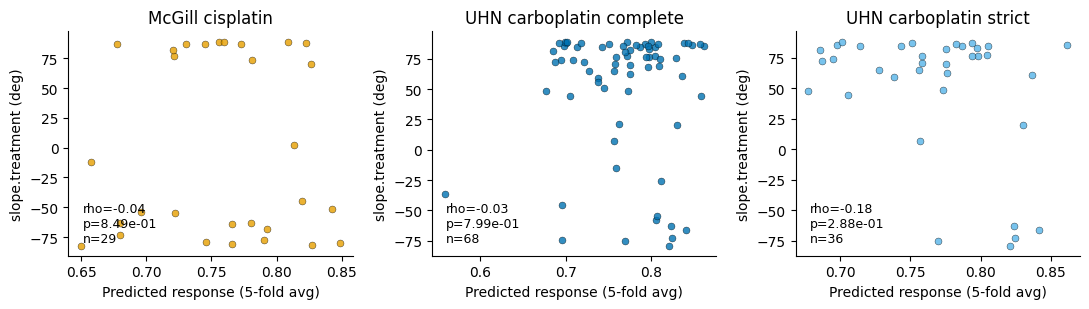

In [6]:
import matplotlib.pyplot as plt

COHORT_PLOT_COLORS = {
    "McGill_cisplatin": "#E69F00",
    "UHN_carboplatin_complete": "#0072B2",
    "UHN_carboplatin_strict": "#56B4E9",
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (name, df) in zip(axes, predictions.items()):
    sub = df.dropna(subset=["average", "slope.treatment"])
    rho, p, n = corr_results[name]
    ax.scatter(sub["average"], sub["slope.treatment"], color=COHORT_PLOT_COLORS[name],
               edgecolor="black", linewidth=0.3, s=25, alpha=0.8)
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("Predicted response (5-fold avg)")
    ax.set_ylabel("slope.treatment (deg)")
    ax.text(0.05, 0.05, f"rho={rho:.2f}\np={p:.2e}\nn={n}", transform=ax.transAxes,
            fontsize=9, va="bottom")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["results"] / "case3_nestvnn_slope_validation.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### AUROC at a fixed absolute threshold (slope.treatment = 0deg: growth vs. regression), with bootstrap CI

In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve


def bootstrap_auroc(y_true, y_score, n_boot=2000, seed=0):
    """Point-estimate AUROC plus the full bootstrap distribution (resampling models with replacement)."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)

    point = roc_auc_score(y_true, y_score)

    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        if yt.min() == yt.max():
            continue  # degenerate resample (single class), skip
        boot_aucs.append(roc_auc_score(yt, y_score[idx]))

    lo, hi = np.percentile(boot_aucs, [2.5, 97.5])
    return point, lo, hi, np.array(boot_aucs)


auroc_results = {}
print("AUROC: predicted response (5-fold average) vs. sensitive (slope.treatment < 0) / resistant (>= 0)")
for name, df in predictions.items():
    sub = df.dropna(subset=["average", "slope.treatment"])
    target = (sub["slope.treatment"] < 0).astype(int)  # 1 = sensitive (net tumor regression)

    point, lo, hi, boot_aucs = bootstrap_auroc(target, sub["average"])
    auroc_results[name] = {
        "auroc": point, "ci_lo": lo, "ci_hi": hi, "n": len(sub),
        "n_sensitive": int(target.sum()), "boot_aucs": boot_aucs,
    }

    print(f"  {name}: n={len(sub)} (sensitive={target.sum()}, resistant={len(sub) - target.sum()}), "
          f"AUROC={point:.3f} [95% CI {lo:.3f}-{hi:.3f}] (n_boot={len(boot_aucs)})")

AUROC: predicted response (5-fold average) vs. sensitive (slope.treatment < 0) / resistant (>= 0)


  McGill_cisplatin: n=29 (sensitive=16, resistant=13), AUROC=0.486 [95% CI 0.260-0.697] (n_boot=2000)


  UHN_carboplatin_complete: n=68 (sensitive=12, resistant=56), AUROC=0.576 [95% CI 0.371-0.771] (n_boot=2000)


  UHN_carboplatin_strict: n=36 (sensitive=5, resistant=31), AUROC=0.839 [95% CI 0.626-0.984] (n_boot=1994)


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_nestvnn_roc.png


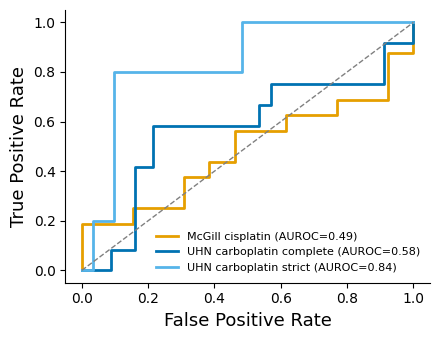

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

for name, df in predictions.items():
    sub = df.dropna(subset=["average", "slope.treatment"])
    target = (sub["slope.treatment"] < 0).astype(int)
    fpr, tpr, _ = roc_curve(target, sub["average"])
    r = auroc_results[name]
    ax.plot(fpr, tpr, color=COHORT_PLOT_COLORS[name], lw=2,
            label=f"{name.replace('_', ' ')} (AUROC={r['auroc']:.2f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize = 13)
ax.set_ylabel("True Positive Rate", fontsize = 13)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["results"] / "case3_nestvnn_roc.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_nestvnn_auroc_boxplot.png


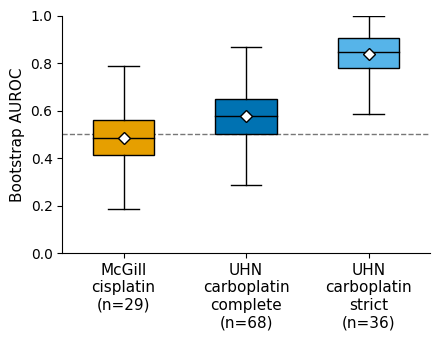

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

names = list(auroc_results.keys())
box_data = [auroc_results[n]["boot_aucs"] for n in names]
colors = [COHORT_PLOT_COLORS[n] for n in names]

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1, zorder=1)

bp = ax.boxplot(
    box_data, positions=np.arange(len(names)), widths=0.5,
    showfliers=False, showmeans=True, patch_artist=True,
    medianprops=dict(color="black"),
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6),
    whiskerprops=dict(color="black"), capprops=dict(color="black"), boxprops=dict(color="black"),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_xticks(np.arange(len(names)))
xticklabels = [n.replace("_", "\n") + f"\n(n={auroc_results[n]['n']})" for n in names]
ax.set_xticklabels(xticklabels, fontsize=11)
ax.set_ylabel("Bootstrap AUROC", fontsize=11)
ax.set_ylim(0, 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["results"] / "case3_nestvnn_auroc_boxplot.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Robustness check: AUROC across bottom-percentile "sensitive" cutoffs (10-90%, per cohort)

In [10]:
PERCENTILES = list(range(10, 100, 10))


def auroc_percentile_sweep(df, percentiles=PERCENTILES, n_boot=1000, seed=0):
    """AUROC (+ bootstrap CI) when 'sensitive' = bottom X% of slope.treatment, per cohort."""
    sub = df.dropna(subset=["average", "slope.treatment"])
    rows = []
    for p in percentiles:
        cutoff = np.percentile(sub["slope.treatment"], p)
        target = (sub["slope.treatment"] < cutoff).astype(int)
        if target.sum() == 0 or target.sum() == len(target):
            continue
        point, lo, hi, _ = bootstrap_auroc(target, sub["average"], n_boot=n_boot, seed=seed)
        rows.append({
            "percentile": p, "cutoff": cutoff, "n_sensitive": int(target.sum()),
            "auroc": point, "ci_lo": lo, "ci_hi": hi,
        })
    return pd.DataFrame(rows)


sweep_results = {name: auroc_percentile_sweep(df) for name, df in predictions.items()}
for name, sweep in sweep_results.items():
    print(f"--- {name} ---")
    print(sweep.to_string(index=False))
    print()

--- McGill_cisplatin ---
 percentile     cutoff  n_sensitive    auroc    ci_lo    ci_hi
         10 -79.933112            3 0.487179 0.000000 0.962963
         20 -74.652616            6 0.608696 0.300000 0.920077
         30 -63.444539            9 0.561111 0.310484 0.794868
         40 -54.433833           12 0.485294 0.266667 0.723896
         50 -44.782399           14 0.504762 0.276137 0.716414
         60  56.551622           17 0.524510 0.299975 0.728626
         70  80.015362           20 0.572222 0.338380 0.784349
         80  86.963242           23 0.413043 0.188796 0.645054
         90  87.584890           26 0.448718 0.200000 0.678571

--- UHN_carboplatin_complete ---
 percentile     cutoff  n_sensitive    auroc    ci_lo    ci_hi
         10 -55.409619            7 0.688525 0.428379 0.887500
         20  20.431573           14 0.588624 0.397345 0.762049
         30  56.358951           21 0.513678 0.345846 0.684097
         40  68.650137           27 0.508582 0.357074 0.655

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_nestvnn_auroc_percentile_sweep.png


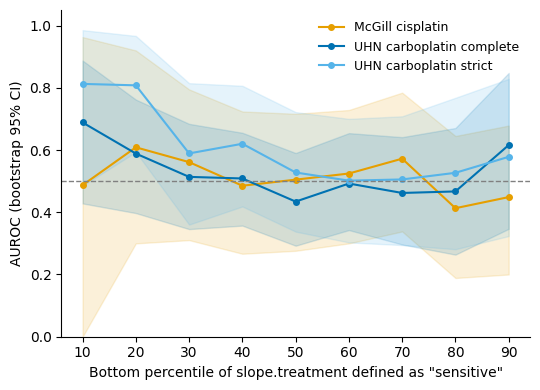

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4))

for name, sweep in sweep_results.items():
    color = COHORT_PLOT_COLORS[name]
    ax.plot(sweep["percentile"], sweep["auroc"], color=color, marker="o", markersize=4,
            label=name.replace("_", " "))
    ax.fill_between(sweep["percentile"], sweep["ci_lo"], sweep["ci_hi"], color=color, alpha=0.15)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Bottom percentile of slope.treatment defined as \"sensitive\"")
ax.set_ylabel("AUROC (bootstrap 95% CI)")
ax.set_ylim(0, 1.05)
ax.set_xticks(PERCENTILES)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["results"] / "case3_nestvnn_auroc_percentile_sweep.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Effect of the response-window cap: capped (10-28 day) vs. uncapped (full duration)

The 10-28 day response window was chosen from the data's own confound structure (window-choice
justification cells in `3-cohort_comparision.ipynb`: McGill's median treatment-arm slope bottoms out
at max.time=28 and erodes at wider windows; the uncensored slope is confounded with follow-up duration
in both cohorts), independent of downstream model performance. Having made that choice on those
grounds, we report its effect on AUROC here as a consequence, not as the basis for the choice --
comparing the current capped label against an uncapped (min.time=10, max.time=NULL) alternative, using
the already-computed uncapped slope.treatment values from `window_confound_sweep.R`.

In [12]:
UNCAPPED_FILE = {
    "McGill_cisplatin": "McGill_slope_full_duration.csv",
    "UHN_carboplatin_complete": "UHN_slope_full_duration.csv",
    "UHN_carboplatin_strict": "UHN_slope_full_duration.csv",
}

uncapped_auroc_results = {}
print("AUROC: predicted response vs. sensitive (slope.treatment < 0) -- capped vs. uncapped")
for name, df in predictions.items():
    uncapped = pd.read_csv(paths["proc"] / UNCAPPED_FILE[name]).rename(
        columns={"slope.treatment": "slope.treatment_uncapped"}
    )
    merged = df.merge(uncapped, on="batch.name", how="left")
    sub = merged.dropna(subset=["average", "slope.treatment_uncapped"])
    target = (sub["slope.treatment_uncapped"] < 0).astype(int)

    point, lo, hi, boot_aucs = bootstrap_auroc(target, sub["average"])
    uncapped_auroc_results[name] = {
        "auroc": point, "ci_lo": lo, "ci_hi": hi, "n": len(sub),
        "n_sensitive": int(target.sum()), "boot_aucs": boot_aucs,
    }

    r_c = auroc_results[name]
    print(f"  {name}:")
    print(f"    capped   (10-28 day): AUROC={r_c['auroc']:.3f} [{r_c['ci_lo']:.3f}-{r_c['ci_hi']:.3f}] "
          f"(sensitive={r_c['n_sensitive']}/{r_c['n']})")
    print(f"    uncapped (full dur.): AUROC={point:.3f} [{lo:.3f}-{hi:.3f}] "
          f"(sensitive={target.sum()}/{len(sub)})")
    print(f"    delta (capped - uncapped): {r_c['auroc'] - point:+.3f}")

AUROC: predicted response vs. sensitive (slope.treatment < 0) -- capped vs. uncapped


  McGill_cisplatin:
    capped   (10-28 day): AUROC=0.486 [0.260-0.697] (sensitive=16/29)
    uncapped (full dur.): AUROC=0.457 [0.231-0.678] (sensitive=15/29)
    delta (capped - uncapped): +0.028


  UHN_carboplatin_complete:
    capped   (10-28 day): AUROC=0.576 [0.371-0.771] (sensitive=12/68)
    uncapped (full dur.): AUROC=0.585 [0.414-0.754] (sensitive=16/68)
    delta (capped - uncapped): -0.009


  UHN_carboplatin_strict:
    capped   (10-28 day): AUROC=0.839 [0.626-0.984] (sensitive=5/36)
    uncapped (full dur.): AUROC=0.762 [0.550-0.950] (sensitive=10/36)
    delta (capped - uncapped): +0.077


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_capped_vs_uncapped_auroc.png


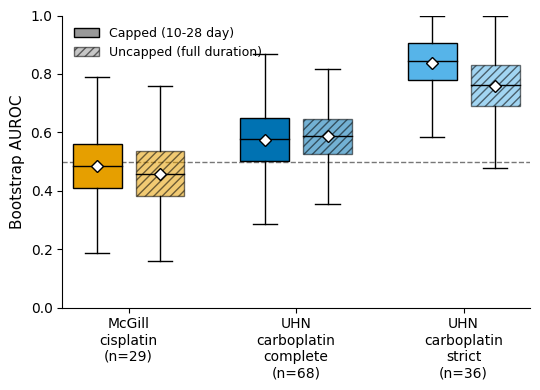

In [13]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5.5, 4))

names = list(predictions.keys())
ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1, zorder=1)

positions, box_data, colors, hatches = [], [], [], []
for i, name in enumerate(names):
    positions += [i * 2.4, i * 2.4 + 0.9]
    box_data += [auroc_results[name]["boot_aucs"], uncapped_auroc_results[name]["boot_aucs"]]
    colors += [COHORT_PLOT_COLORS[name], COHORT_PLOT_COLORS[name]]
    hatches += [None, "////"]

bp = ax.boxplot(
    box_data, positions=positions, widths=0.7,
    showfliers=False, showmeans=True, patch_artist=True,
    medianprops=dict(color="black"),
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6),
    whiskerprops=dict(color="black"), capprops=dict(color="black"), boxprops=dict(color="black"),
)
for patch, color, hatch in zip(bp["boxes"], colors, hatches):
    patch.set_facecolor(color)
    patch.set_alpha(0.55 if hatch else 1.0)
    if hatch:
        patch.set_hatch(hatch)

ax.set_xticks([i * 2.4 + 0.45 for i in range(len(names))])
ax.set_xticklabels(
    [nm.replace("_", "\n") + f"\n(n={auroc_results[nm]['n']})" for nm in names], fontsize=10
)
ax.set_ylabel("Bootstrap AUROC", fontsize=11)
ax.set_ylim(0, 1)

legend_handles = [
    Patch(facecolor="0.6", edgecolor="black", label="Capped (10-28 day)"),
    Patch(facecolor="0.6", edgecolor="black", hatch="////", alpha=0.55, label="Uncapped (full duration)"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper left", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["results"] / "case3_capped_vs_uncapped_auroc.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()